### Open and Rename columns

In [1]:
import pandas as pd
file= "Site.csv"
df = pd.read_csv(file)
df

,Point No,Northing,Easting,Elavation,Code
0,9000,1000.000,1000.0004,100.000,CP
1,9001,1016.408,1004.0870,99.986,CP
2,1,1016.498,1010.3710,99.933,BUILD
3,2,1018.254,1009.9230,99.787,BUILD
4,3,1000.165,1000.9500,100.005,BUILD
...,...,...,...,...,...
279,276,971.295,1006.1770,115.328,P
280,277,972.824,1004.2440,115.335,P
281,278,973.538,1003.4310,115.345,P
282,279,972.693,1002.7950,115.354,P


In [2]:
# @title
df.columns = df.columns.str.strip()
print(df.columns)
df = df.rename(columns={
    "Point No": "id",
    "Northing": "y",
    "Easting": "x",
    "Elavation": "z",
    "Code": "type"
})

print(df.columns)
DEMfile="site_DEM.csv"
df.to_csv(DEMfile, index=False)

Index(['Point No', 'Northing', 'Easting', 'Elavation', 'Code'], dtype='object')
Index(['id', 'y', 'x', 'z', 'type'], dtype='object')


### Read *DEM*

In [3]:
# @title
df = pd.read_csv(DEMfile)

print("Data preview:")
display(df.tail(20))

print("\nColumns:")
print(df.columns.tolist())

print("\nPoint count by type:")
print(df["type"].value_counts())




Data preview:


,id,y,x,z,type
264,261,962.908,1000.629,120.945,P
265,262,959.986,1002.448,121.140,P
266,263,957.267,1004.141,121.149,P
267,264,954.676,1005.641,121.220,P
268,265,952.193,1007.948,121.065,P
269,266,949.743,1008.745,121.316,P
270,267,958.635,1017.872,114.994,P
271,268,959.700,1017.910,114.693,P
272,269,961.130,1018.990,114.557,P
273,270,960.946,1016.633,115.368,P



Columns:
['id', 'y', 'x', 'z', 'type']

Point count by type:
type
P        171
Dn        35
ROCK      23
DN        21
p         14
Roack      6
BUILD      5
Rock       3
CP         3
RP         2
BW         1
Name: count, dtype: int64


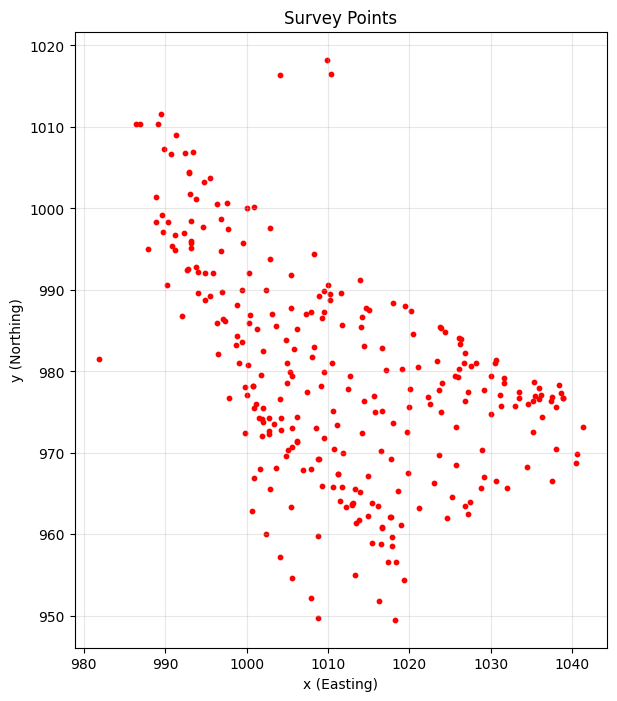

In [5]:
# @title
import matplotlib.pyplot as plt

# =========================================================
# 3. Plot survey points only
# =========================================================
plt.figure(figsize=(8, 8))
plt.scatter(df["x"], df["y"], s=10, c="red")
plt.xlabel("x (Easting)")
plt.ylabel("y (Northing)")
plt.title("Survey Points")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# @title
# =========================================================
# 5. Basic coverage summary
# =========================================================
print("\nCoverage summary")
print("Total points:", len(df))
print("x range:", df["x"].min(), "to", df["x"].max())
print("y range:", df["y"].min(), "to", df["y"].max())
print("z range:", df["z"].min(), "to", df["z"].max())
#print("Points in far building-end zone:", len(df_far))




Coverage summary
Total points: 284
x range: 981.865 to 1041.298
y range: 949.526 to 1018.254
z range: 99.756 to 121.316


In [7]:
print(df["type"].unique())


['CP' 'BUILD' 'Rock' 'ROCK' 'P' 'Dn' 'RP' 'p' 'Roack' 'BW' 'DN']


In [8]:
# Convert to string (safe) and clean
df["type"] = df["type"].astype(str)

# Replace variations
df["type"] = df["type"].replace({
    "Rock": "ROCK",
    "Roack": "ROCK",
    "Dn": "DN",
    "p": "P",
    "BUILD": "BC",
    "BUILDING AREA":"BA",
    "building area":"BA"
})

# (Optional but recommended) make everything uppercase
df["type"] = df["type"].str.upper()

# Check result
print(df["type"].unique())
print(df["type"].value_counts())

['CP' 'BC' 'ROCK' 'P' 'DN' 'RP' 'BW']
type
P       185
DN       56
ROCK     32
BC        5
CP        3
RP        2
BW        1
Name: count, dtype: int64


In [9]:
import pandas as pd
import numpy as np

# =========================================================
# 1. Load your survey data (already renamed)
# df must have: x, y, z, type
# =========================================================

# ---------------------------------------------------------
# 2. Get site extent
# ---------------------------------------------------------
x_min, x_max = df["x"].min(), df["x"].max()
y_min, y_max = df["y"].min(), df["y"].max()

# ---------------------------------------------------------
# 5. Create building dataframe
# ---------------------------------------------------------
tbm1_level = 99.986 #1000, 1000 TBM 1

df_assumed = pd.DataFrame({
    "id": [1000, 1001, 1002, 1003, 1004, 1005],
    "x":  [1002.0, 1006.0, 1010.0, 1010.0, 1006.0, 1002.0],
    "y":  [1012.0, 1012.0, 1012.0, 1016.0, 1016.0, 1016.0],
    "z":  [tbm1_level]*6,  #repeats the value 6 times to match the number of rows.
    "type": ["AP"]*6
})

display(df_assumed)


,id,x,y,z,type
0,1000,1002.0,1012.0,99.986,AP
1,1001,1006.0,1012.0,99.986,AP
2,1002,1010.0,1012.0,99.986,AP
3,1003,1010.0,1016.0,99.986,AP
4,1004,1006.0,1016.0,99.986,AP
5,1005,1002.0,1016.0,99.986,AP


In [10]:
df_building = df [df["type"] == "BC"]
df_building

,id,y,x,z,type
2,1,1016.498,1010.371,99.933,BC
3,2,1018.254,1009.923,99.787,BC
4,3,1000.165,1000.950,100.005,BC
6,5,978.354,1038.353,100.055,BC
7,6,976.694,1038.834,99.899,BC


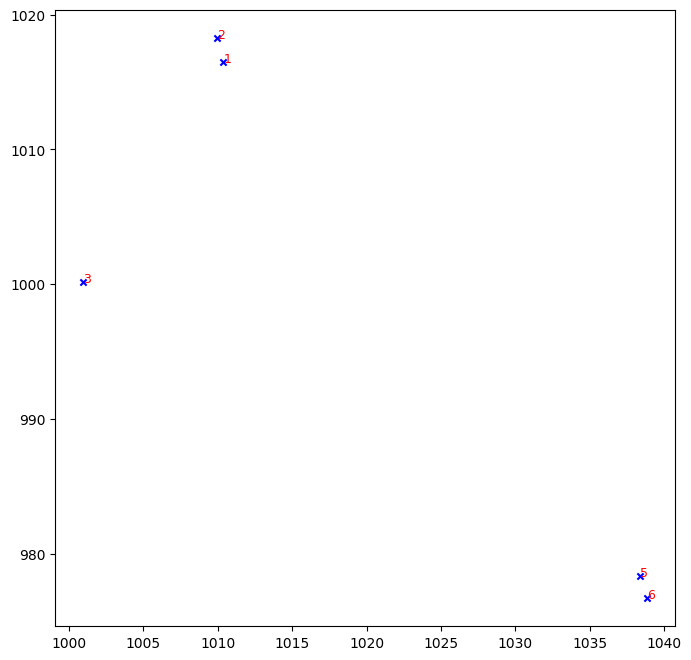

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,8))

# measured
#plt.scatter(df["x"], df["y"], c="red", s=1, label="Measured")

# building
plt.scatter(df_building["x"], df_building["y"],
            c="blue", s=20, marker="x", label="Building")

for _, row in df_building.iterrows():
    plt.text(row["x"], row["y"], str(row["id"]),  c="red" , fontsize=9)


plt.show()

In [12]:

df_assumed = df_assumed[df_assumed["id"] != 1003]
df_assumed = df_assumed[df_assumed["id"] != 1004]
df_assumed = df_assumed[df_assumed["id"] != 1005]
df_assumed.loc[df_assumed["id"] == 1001, ["x", "y"]] = [1040, 990]
df_assumed.loc[df_assumed["id"] == 1000, ["x", "y"]] = [1030, 1000]

In [ ]:
df_assumed

,id,x,y,z,type
0,1000,1030.0,1000.0,99.986,AP
1,1001,1040.0,990.0,99.986,AP
2,1002,1010.0,1012.0,99.986,AP


Text(0.5, 1.0, 'Auto-generated Building Points')

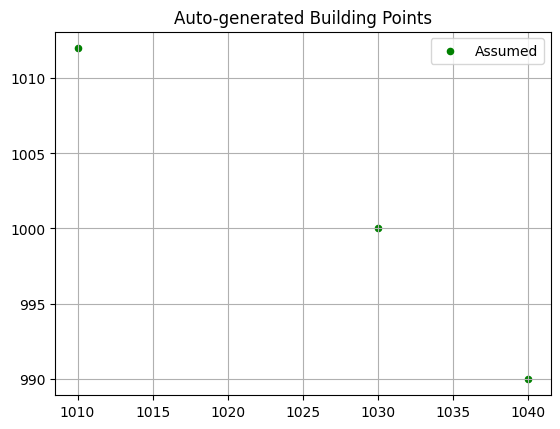

In [13]:
plt.scatter(df_assumed["x"], df_assumed["y"], c="green", s=20, label="Assumed")

plt.gca().set_aspect("equal")
plt.legend()
plt.grid(True)
plt.title("Auto-generated Building Points")

### Combine

In [14]:
import pandas as pd

# Merge
df_combined = pd.concat([df, df_assumed], ignore_index=True)

print("Total points:", len(df_combined))
df_combined.head()

Total points: 287


,id,y,x,z,type
0,9000,1000.000,1000.0004,100.000,CP
1,9001,1016.408,1004.0870,99.986,CP
2,1,1016.498,1010.3710,99.933,BC
3,2,1018.254,1009.9230,99.787,BC
4,3,1000.165,1000.9500,100.005,BC


In [15]:
df_combined = df_combined[df_combined['type'] != 'Dn']
df_combined = df_combined[df_combined['type'] != 'BW']

df_combined = df_combined.dropna(subset=["x", "y", "z"])

print("Missing x:", df_combined["x"].isnull().sum())
print("Missing y:", df_combined["y"].isnull().sum())
print("Missing z:", df_combined["z"].isnull().sum())

Missing x: 0
Missing y: 0
Missing z: 0


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# =========================================================
# 1. HELPER: ORDER POLYGON POINTS CLOCKWISE
# =========================================================
def order_points_clockwise(df_pts):
    pts = df_pts[["x", "y"]].dropna().to_numpy()
    if len(pts) < 3:
        return pts

    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean()

    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    order = np.argsort(angles)

    return pts[order]

# =========================================================
# 2. SELECT FEATURE POINTS
# =========================================================
df_build = df_combined[df_combined["type"] == "BC"]
df_rock  = df_combined[df_combined["type"] == "ROCK"]

build_xy = order_points_clockwise(df_build)
rock_xy  = order_points_clockwise(df_rock)
'''
# =========================================================
# 3. GRID FOR DEM
# =========================================================
# Better to use meshgrid for plotting clarity
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# =========================================================
# 4. INTERPOLATE SURFACE
# =========================================================
Zi = griddata((x, y), z, (Xi, Yi), method="linear")

# Fill NaN edges using nearest
Zi_nearest = griddata((x, y), z, (Xi, Yi), method="nearest")
Zi[np.isnan(Zi)] = Zi_nearest[np.isnan(Zi)]

# =========================================================
# 5. CONTOUR LEVELS
# =========================================================
z_min = np.floor(np.nanmin(Zi))
z_max = np.ceil(np.nanmax(Zi))
levels = np.arange(z_min, z_max + 1, 1)

# =========================================================
# 6. SCALE BAR
# =========================================================
def add_scale_bar(length=10, label="10 m"):
    ax = plt.gca()
    fontprops = fm.FontProperties(size=8)

    scalebar = AnchoredSizeBar(
        ax.transData,
        length,
        label,
        "lower right",
        pad=0.3,
        alpha=0.5,
        color="black",
        frameon=False,
        size_vertical=0.5,
        fontproperties=fontprops
    )
    ax.add_artist(scalebar)

# =========================================================
# 7. PLOT
# =========================================================
plt.figure(figsize=(8, 8))

# Optional survey points
# plt.scatter(x, y, s=4, c="lightblue", label="Survey Points")

# BUILD polygon
if len(build_xy) >= 3:
    build_closed = np.vstack([build_xy, build_xy[0]])
    plt.plot(
        build_closed[:, 0],
        build_closed[:, 1],
        color="black",
        linewidth=1.2,
        label="BUILD"
    )

# ROCK polygon
if len(rock_xy) >= 3:
    rock_closed = np.vstack([rock_xy, rock_xy[0]])
    plt.plot(
        rock_closed[:, 0],
        rock_closed[:, 1],
        color="brown",
        linewidth=1.2,
        label="ROCK"
    )

# Contours
cs = plt.contour(
    Xi, Yi, Zi,
    levels=levels,
    colors="brown",
    linewidths=0.5
)

plt.clabel(cs, inline=True, fontsize=8, fmt="%.0f")

# =========================================================
# 8. FORMAT
# =========================================================
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True, alpha=0.5)
plt.title("Ranawana Raw Map")
plt.tight_layout()
add_scale_bar(length=10, label="10 m")

# Optional legend
# plt.legend()

# =========================================================
# 9. SAVE
# =========================================================
plt.savefig("Ranawana_Infra_Map.png", dpi=300, bbox_inches="tight")
plt.savefig("Ranawana_Infra_Map.pdf", dpi=300, bbox_inches="tight")

plt.show()
'''

'\n# =========================================================\n# 3. GRID FOR DEM\n# =========================================================\n# Better to use meshgrid for plotting clarity\nxi = np.linspace(x.min(), x.max(), 200)\nyi = np.linspace(y.min(), y.max(), 200)\nXi, Yi = np.meshgrid(xi, yi)\n\n# =========================================================\n# 4. INTERPOLATE SURFACE\n# =========================================================\nZi = griddata((x, y), z, (Xi, Yi), method="linear")\n\n# Fill NaN edges using nearest\nZi_nearest = griddata((x, y), z, (Xi, Yi), method="nearest")\nZi[np.isnan(Zi)] = Zi_nearest[np.isnan(Zi)]\n\n# =========================================================\n# 5. CONTOUR LEVELS\n# =========================================================\nz_min = np.floor(np.nanmin(Zi))\nz_max = np.ceil(np.nanmax(Zi))\nlevels = np.arange(z_min, z_max + 1, 1)\n\n# =========================================================\n# 6. SCALE BAR\n# =====================

In [19]:
df_build

,id,y,x,z,type
2,1,1016.498,1010.371,99.933,BC
3,2,1018.254,1009.923,99.787,BC
4,3,1000.165,1000.950,100.005,BC
6,5,978.354,1038.353,100.055,BC
7,6,976.694,1038.834,99.899,BC


### Data Fixing

In [20]:
temp= df_combined[df_combined['id']==141]

temp

,id,y,x,z,type
144,141,967.378,1011.254,114.918,P


In [21]:
df_combined = df_combined[df_combined['id'] != 204]
df_combined = df_combined[df_combined['id'] != 139]
df_combined = df_combined[df_combined['id'] != 140]

#re run rerrain

,id,y,x,z,type,dist
141,139,980.974,1030.503,115.343,P,8.582182


In [22]:
df_combined["type"].unique()

array(['CP', 'BC', 'ROCK', 'P', 'DN', 'RP', 'AP'], dtype=object)

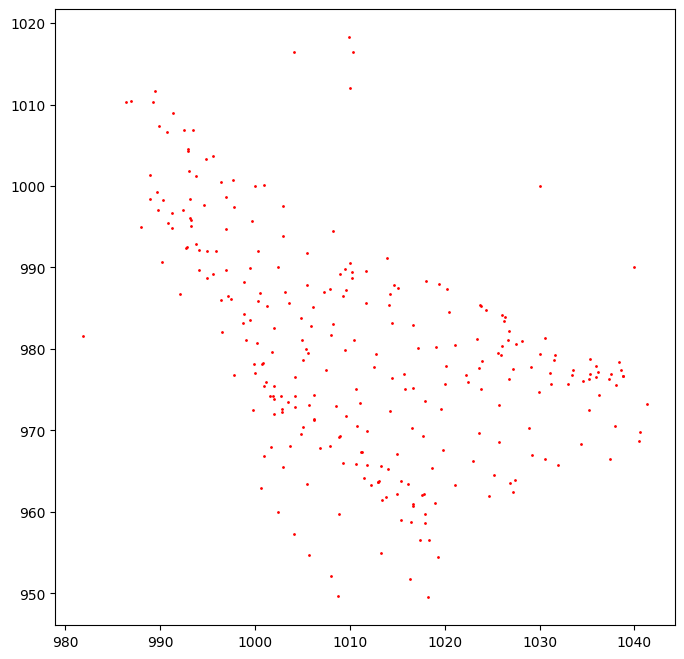

In [23]:


plt.figure(figsize=(8,8))

# measured
plt.scatter(df_combined["x"], df_combined["y"], c="red", s=1, label="Combined")

# building
#plt.scatter(df_building["x"], df_building["y"],
            #c="blue", s=20, marker="x", label="Building")

#for _, row in df_building.iterrows():
  #  plt.text(row["x"], row["y"], str(row["id"]),  c="red" , fontsize=9)


plt.show()

### Final Data Points Stats

In [24]:
import numpy as np
from scipy.interpolate import griddata

df_combined = df_combined.dropna(subset=["x", "y", "z"])

# Extract arrays
x = df_combined["x"].values
y = df_combined["y"].values
z = df_combined["z"].values

# Create grid
grid_x, grid_y = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

# Interpolate surface
grid_z = griddata((x, y), z, (grid_x, grid_y), method="cubic")
print(x.min(),x.max())
print(y.min(),y.max())
print(z.min(),z.max())

print("Missing x:", df_combined["x"].isnull().sum())
print("Missing y:", df_combined["y"].isnull().sum())
print("Missing z:", df_combined["z"].isnull().sum())

981.865 1041.298
949.526 1018.254
99.756 121.316
Missing x: 0
Missing y: 0
Missing z: 0


### Profile Print

### Infrastructure

In [26]:
df_combined["dist"] = np.sqrt(
    (df_combined["x"] - 1032.02)**2 +
    (df_combined["y"] - 980.02)**2 +
    (df_combined["z"] - 106.95)**2
)
#df_combined["dist"]
closest = df_combined.nsmallest(3, "dist")
print(closest[["x", "y", "z", "dist"]])

           x        y        z      dist
83  1031.179  975.709  105.442  4.643928
82  1032.941  975.755  105.224  4.692285
84  1027.166  977.493  105.653  5.623989


In [ ]:
df_combined

,id,y,x,z,type,dist
0,9000,1000.000,1000.0004,100.000,CP,38.376525
1,9001,1016.408,1004.0870,99.986,CP,46.398667
2,1,1016.498,1010.3710,99.933,BC,42.994906
3,2,1018.254,1009.9230,99.787,BC,44.737286
4,3,1000.165,1000.9500,100.005,BC,37.674911
...,...,...,...,...,...,...
282,279,972.693,1002.7950,115.354,P,31.279590
283,9004,975.950,1001.1920,115.105,RP,32.147076
284,1000,1000.000,1030.0000,99.986,AP,21.255072
285,1001,990.000,1040.0000,99.986,AP,14.552598


### Save Clean NPZ

In [30]:
# ---------------------------------------------------------
# 7. LOCAL SPIKE / OUTLIER FILTER
# ---------------------------------------------------------

from scipy.spatial import cKDTree

# Extract arrays from dataframe
xp = df_combined["x"].to_numpy()
yp = df_combined["y"].to_numpy()
zp = df_combined["z"].to_numpy()
points = np.column_stack((xp, yp))
tree = cKDTree(points)

mask = np.ones(len(zp), dtype=bool)

threshold = 2.5   # meters difference, adjust if needed
k_neighbors = 6   # point itself + 5 neighbors

for i in range(len(zp)):
    dists, idxs = tree.query(points[i], k=k_neighbors)

    neighbor_z = zp[idxs[1:]]   # exclude the point itself

    local_mean = np.mean(neighbor_z)
    local_std = np.std(neighbor_z)

    if np.abs(zp[i] - local_mean) > max(threshold, 2 * local_std):
        mask[i] = False

# Filtered arrays
xp_clean = xp[mask]
yp_clean = yp[mask]
zp_clean = zp[mask]

print("\nSpike filtering summary:")
print("Original:", len(zp))
print("Filtered:", len(zp_clean))
print("Removed:", len(zp) - len(zp_clean))

# ---------------------------------------------------------
# 8. SHOW REMOVED POINTS
# ---------------------------------------------------------
removed = ~mask
removed_points = pd.DataFrame({
    "x": xp[removed],
    "y": yp[removed],
    "z": zp[removed]
})

print("\nRemoved spike points:")
display(removed_points)

# ---------------------------------------------------------
# 9. CREATE FINAL CLEAN DATAFRAME
# ---------------------------------------------------------
df_final_clean = pd.DataFrame({
    "x": xp_clean,
    "y": yp_clean,
    "z": zp_clean
})

# If you want to preserve id/type too, filter original cleaned dataframe
df_final_clean = df_combined.loc[mask].copy()

# ---------------------------------------------------------
# 10. FINAL VALIDATION
# ---------------------------------------------------------
print("\nFinal cleaned dataset summary:")
print("Total rows:", len(df_final_clean))
print("Missing x:", df_final_clean["x"].isnull().sum())
print("Missing y:", df_final_clean["y"].isnull().sum())
print("Missing z:", df_final_clean["z"].isnull().sum())

print("\nData types:")
print(df_final_clean.dtypes)

# ---------------------------------------------------------
# 11. SITE EXTENT
# ---------------------------------------------------------
print("\nExtent:")
print("x min:", df_final_clean["x"].min())
print("x max:", df_final_clean["x"].max())
print("y min:", df_final_clean["y"].min())
print("y max:", df_final_clean["y"].max())
print("z min:", df_final_clean["z"].min())
print("z max:", df_final_clean["z"].max())


# ---------------------------------------------------------
# 12. SAVE CLEAN CSV
# ---------------------------------------------------------
df_final_clean.to_csv("Site_DEM_points.csv", index=False)
print("\nSaved: Site_DEM_points.csv")

# ---------------------------------------------------------
# 13. SAVE CLEAN NPZ
# ---------------------------------------------------------
df_dem=df_final_clean
np.savez(
    "Site_DEM_points.npz",
    x=df_dem["x"].to_numpy(),
    y=df_dem["y"].to_numpy(),
    z=df_dem["z"].to_numpy(),
    id=df_dem["id"].to_numpy()
)
print("Saved: Site_DEM_points.npz")





Spike filtering summary:
Original: 283
Filtered: 280
Removed: 3

Removed spike points:


,x,y,z
0,1020.451,984.589,104.307
1,995.861,992.057,106.163
2,1025.630,979.448,105.399



Final cleaned dataset summary:
Total rows: 280
Missing x: 0
Missing y: 0
Missing z: 0

Data types:
id        int64
y       float64
x       float64
z       float64
type     object
dist    float64
dtype: object

Extent:
x min: 981.865
x max: 1041.298
y min: 949.526
y max: 1018.254
z min: 99.756
z max: 121.316

Saved: Site_DEM_points.csv
Saved: Site_DEM_points.npz


### Load Model

### Plot RAW

In [31]:
import numpy as np
import pandas as pd

data = np.load("Site_DEM_points.npz")

x = data["x"]
y = data["y"]
z = data["z"]
id = data["id"]
print("Loaded points:", len(x))

Loaded points: 280


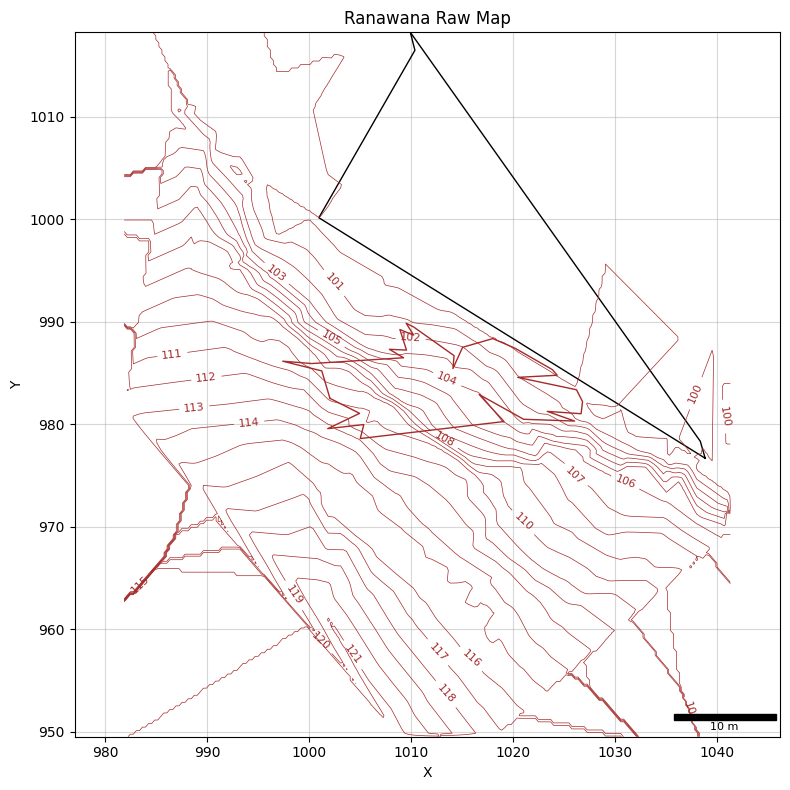

In [32]:
# @title
import matplotlib.pyplot as plt


import numpy as np

def order_points_clockwise(df_pts):
    pts = df_pts[["x", "y"]].dropna().to_numpy()
    if len(pts) < 3:
        return pts

    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean()

    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    order = np.argsort(angles)

    return pts[order]


df_build =df_combined[df_combined['type'] == 'BC']
df_rock = df_combined[df_combined['type'] == 'ROCK']

build_xy = order_points_clockwise(df_build)
rock_xy  = order_points_clockwise(df_rock)
#Dn_xy  = order_points_clockwise(df_Dn)
#DN_xy  = order_points_clockwise(df_DN)

# DN often represents a drain line, so sort roughly along x then y
# Dn_xy = df_Dn[["x", "y"]].dropna().sort_values(by=["x", "y"]).to_numpy()
# DN often represents a drain line, so sort roughly along x then y
#DN_xy = df_DN[["x", "y"]].dropna().sort_values(by=["x", "y"]).to_numpy()

plt.figure(figsize=(8, 8))

# all survey points in background
#plt.scatter(df_combined_clean["x"], df_combined_clean["y"], s=4, c="lightblue")

# BUILD polygon
if len(build_xy) >= 3:
    build_closed = np.vstack([build_xy, build_xy[0]])
    plt.plot(build_closed[:, 0], build_closed[:, 1], color="black", linewidth=1, label="BUILD")

# ROCK polygon
if len(rock_xy) >= 3:
    rock_closed = np.vstack([rock_xy, rock_xy[0]])
    plt.plot(rock_closed[:, 0], rock_closed[:, 1], color="brown", linewidth=1, label="ROCK")

Xi, Yi = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

# =========================================================
# 3. Interpolate surface
#    linear is safer for engineering terrain
# =========================================================
Zi = griddata((x, y), z, (Xi, Yi), method="linear")

# Fill edge NaN values using nearest
Zi_nearest = griddata((x, y), z, (Xi, Yi), method="nearest")
Zi[np.isnan(Zi)] = Zi_nearest[np.isnan(Zi)]

# =========================================================
# 4. Create 1 m contour levels
# =========================================================
z_min = np.floor(np.nanmin(Zi))
z_max = np.ceil(np.nanmax(Zi))
levels = np.arange(z_min, z_max + 1, 1)

# =========================================================
# 5. Plot

cs = plt.contour(
    Xi, Yi, Zi,
    levels=levels,
    colors="brown",
    linewidths=0.5
)

plt.clabel(cs, inline=True, fontsize=8, fmt="%.0f")
'''

if len(DN_xy) >= 2:
    plt.plot(DN_xy[:, 0], DN_xy[:, 1], color="red", linewidth=1, label="DN")


# Dn line
if len(dn_xy) >= 2:
    plt.plot(dn_xy[:, 0], dn_xy[:, 1], color="blue", linewidth=1, label="Dn")
    #plt.scatter(dn_xy[:, 0], dn_xy[:, 1], s=2, c="brown")
'''

#plt.plot(DN_xy[:, 0], DN_xy[:, 1], color="red", linewidth=6, label="DN")
#plt.plot(dn_xy[:, 0], dn_xy[:, 1], color="blue", linewidth=3, label="Dn", alpha=0.5,)

def scale_bar ():
  # ---- Scale bar ----
  from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
  import matplotlib.font_manager as fm

  ax = plt.gca()
  fontprops = fm.FontProperties(size=8)

  scalebar = AnchoredSizeBar(
      ax.transData,
      10,        # 10 units (meters if your data is in meters)
      '10 m',
      'lower right',
      pad=0.3,
      alpha=0.5,
      color='black',
      frameon=False,
      size_vertical=0.5,
      fontproperties=fontprops
  )

  ax.add_artist(scalebar)

plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True, alpha=0.5)
#plt.legend()
plt.title("Ranawana Raw Map")
plt.tight_layout()
scale_bar()
plt.savefig("Ranawana_Infra_Map.png", dpi=300, bbox_inches="tight")
plt.savefig("Ranawana_Infra_Map.pdf", dpi=300, bbox_inches="tight")
plt.show()

### 3 D View

In [33]:
# @title
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# =========================================================
# 1. HELPER: ORDER POLYGON POINTS CLOCKWISE
# =========================================================
def order_points_clockwise(df_pts):
    pts = df_pts[["x", "y"]].dropna().to_numpy()
    if len(pts) < 3:
        return pts

    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean()

    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    order = np.argsort(angles)

    return pts[order]

# =========================================================
# 2. HELPER: SAMPLE Z VALUES FOR XY LINES/POLYGONS
# =========================================================
def sample_z_values(xy, x, y, z):
    if len(xy) == 0:
        return np.array([])

    zs = griddata((x, y), z, (xy[:, 0], xy[:, 1]), method="linear")
    zs_nearest = griddata((x, y), z, (xy[:, 0], xy[:, 1]), method="nearest")

    if zs is None:
        zs = zs_nearest
    else:
        zs[np.isnan(zs)] = zs_nearest[np.isnan(zs)]

    return zs

# =========================================================
# 3. FILTER FEATURES
# =========================================================
df_build = df_combined[df_combined["type"] == "BC"]
df_rock  = df_combined[df_combined["type"] == "ROCK"]

build_xy = order_points_clockwise(df_build)
rock_xy  = order_points_clockwise(df_rock)

# =========================================================
# 4. CREATE GRID
# =========================================================
Xi, Yi = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

# =========================================================
# 5. INTERPOLATE TERRAIN
# =========================================================
Zi = griddata((x, y), z, (Xi, Yi), method="linear")

# Fill missing values using nearest
Zi_nearest = griddata((x, y), z, (Xi, Yi), method="nearest")
Zi[np.isnan(Zi)] = Zi_nearest[np.isnan(Zi)]

# =========================================================
# 6. CONTOUR LEVELS
# =========================================================
z_min = np.floor(np.nanmin(Zi))
z_max = np.ceil(np.nanmax(Zi))
levels = np.arange(z_min, z_max + 1, 1)

# =========================================================
# 7. CREATE FIGURE
# =========================================================
fig = go.Figure()

# =========================================================
# 8. ADD TERRAIN SURFACE
# =========================================================
fig.add_trace(go.Surface(
    x=Xi,
    y=Yi,
    z=Zi,
    colorscale="Earth",   # change to "Greys" if needed
    opacity=0.90,
    showscale=True,
    colorbar=dict(title="Elevation (m)"),
    name="Terrain",
    hovertemplate="X: %{x:.2f}<br>Y: %{y:.2f}<br>Z: %{z:.2f}<extra></extra>"
))

# =========================================================
# 9. EXTRACT CONTOUR SEGMENTS USING MATPLOTLIB
# =========================================================
tmp_fig, tmp_ax = plt.subplots(figsize=(6, 6))
cs = tmp_ax.contour(Xi, Yi, Zi, levels=levels)
plt.close(tmp_fig)

# Use allsegs instead of collections
for i, segs in enumerate(cs.allsegs):
    level = cs.levels[i]

    for seg in segs:
        if seg is None or len(seg) < 2:
            continue

        xs = seg[:, 0]
        ys = seg[:, 1]
        zs = np.full(len(xs), level + 0.05)  # lift a little above terrain

        fig.add_trace(go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode="lines",
            line=dict(color="brown", width=2),
            showlegend=False,
            hovertemplate=f"Contour: {level:.0f} m<extra></extra>"
        ))

# =========================================================
# 10. ADD BUILD POLYGON
# =========================================================
if len(build_xy) >= 3:
    build_closed = np.vstack([build_xy, build_xy[0]])
    build_z = sample_z_values(build_closed, x, y, z) + 0.20

    fig.add_trace(go.Scatter3d(
        x=build_closed[:, 0],
        y=build_closed[:, 1],
        z=build_z,
        mode="lines",
        line=dict(color="black", width=6),
        name="BUILD",
        hovertemplate="BUILD<extra></extra>"
    ))

# =========================================================
# 11. ADD ROCK POLYGON
# =========================================================
if len(rock_xy) >= 3:
    rock_closed = np.vstack([rock_xy, rock_xy[0]])
    rock_z = sample_z_values(rock_closed, x, y, z) + 0.20

    fig.add_trace(go.Scatter3d(
        x=rock_closed[:, 0],
        y=rock_closed[:, 1],
        z=rock_z,
        mode="lines",
        line=dict(color="brown", width=6),
        name="ROCK",
        hovertemplate="ROCK<extra></extra>"
    ))

# =========================================================
# 12. OPTIONAL: ADD SURVEY POINTS
# =========================================================
fig.add_trace(go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode="markers",
    marker=dict(size=2, color="blue"),
    name="Survey Points",
    opacity=0.5,
    hovertemplate="X: %{x:.2f}<br>Y: %{y:.2f}<br>Z: %{z:.2f}<extra></extra>"
))

# =========================================================
# 13. LAYOUT
# =========================================================
fig.update_layout(
    title="Ranawana Interactive Terrain Map",
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Elevation (m)",
        aspectmode="data",
        camera=dict(
            eye=dict(x=1.6, y=1.6, z=0.8)
        )
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=0, b=0, t=40)
)

# =========================================================
# 14. SAVE OUTPUT
# =========================================================
fig.write_html("Ranawana_Interactive_Terrain.html")

# Optional static image export if kaleido is installed
# fig.write_image("Ranawana_Interactive_Terrain.png", width=1600, height=1200, scale=2)

# =========================================================
# 15. SHOW
# =========================================================
fig.show()

### Cleaning

### LOCAL SPIKE / OUTLIER FILTER

In [34]:
# =========================================================
# DATA VALIDATION + CLEANING BEFORE DEM
# =========================================================

import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ---------------------------------------------------------
# 1. Convert x, y, z to numeric
# ---------------------------------------------------------
for col in ["x", "y", "z"]:
    df_combined[col] = pd.to_numeric(df_combined[col], errors="coerce")

# ---------------------------------------------------------
# 2. Show missing values summary
# ---------------------------------------------------------
print("Missing values summary:")
print(df_combined[["x", "y", "z"]].isnull().sum())

# ---------------------------------------------------------
# 3. Show rows with problems
# ---------------------------------------------------------
bad_rows = df_combined[df_combined[["x", "y", "z"]].isnull().any(axis=1)]

print("\nRows with missing / invalid x, y, or z:")
display(bad_rows)

#---------------------------------------------------------
# 4. Remove bad rows
# ---------------------------------------------------------
df_combined_clean = df_combined.dropna(subset=["x", "y", "z"]).copy()


# ---------------------------------------------------------
# 5. Check duplicates by x,y,z
# ---------------------------------------------------------
dupes = df_combined_clean[
    df_combined_clean.duplicated(subset=["x", "y", "z"], keep=False)
]

print("\nDuplicate xyz rows:")
display(dupes)

#
# Optional: remove exact duplicates
df_combined_clean = df_combined_clean.drop_duplicates(subset=["x", "y", "z"]).copy()

# ---------------------------------------------------------
# 6. CREATE POINT ARRAYS FROM CLEAN DATAFRAME
# ---------------------------------------------------------
xp = df_combined_clean["x"].to_numpy()
yp = df_combined_clean["y"].to_numpy()
zp = df_combined_clean["z"].to_numpy()

print("\nArray lengths before spike filtering:")
print("len(xp):", len(xp))
print("len(yp):", len(yp))
print("len(zp):", len(zp))


Missing values summary:
x    0
y    0
z    0
dtype: int64

Rows with missing / invalid x, y, or z:


,id,y,x,z,type,dist



Duplicate xyz rows:


,id,y,x,z,type,dist



Array lengths before spike filtering:
len(xp): 283
len(yp): 283
len(zp): 283


### Analysis

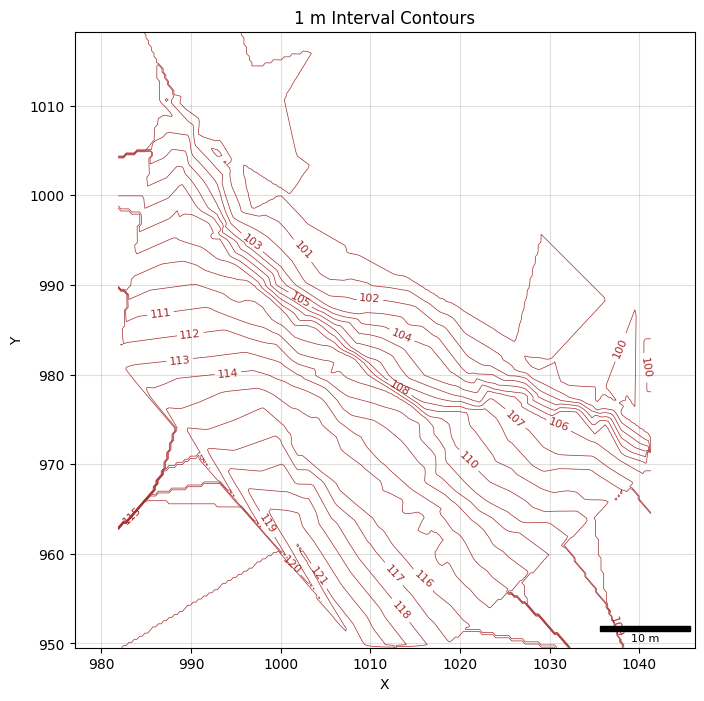

In [35]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =========================================================
# 1. Open NPZ
# =========================================================
df_dem = np.load("Site_DEM_points.npz")

x = df_dem["x"]
y = df_dem["y"]
z = df_dem["z"]

# =========================================================
# 2. Create interpolation grid
# =========================================================
Xi, Yi = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

# =========================================================
# 3. Interpolate surface
#    linear is safer for engineering terrain
# =========================================================
Zi = griddata((x, y), z, (Xi, Yi), method="linear")

# Fill edge NaN values using nearest
Zi_nearest = griddata((x, y), z, (Xi, Yi), method="nearest")
Zi[np.isnan(Zi)] = Zi_nearest[np.isnan(Zi)]

# =========================================================
# 4. Create 1 m contour levels
# =========================================================
z_min = np.floor(np.nanmin(Zi))
z_max = np.ceil(np.nanmax(Zi))
levels = np.arange(z_min, z_max + 1, 1)

# =========================================================
# 5. Plot
# =========================================================
plt.figure(figsize=(8, 8))

cs = plt.contour(
    Xi, Yi, Zi,
    levels=levels,
    colors="brown",
    linewidths=0.5
)

plt.clabel(cs, inline=True, fontsize=8, fmt="%.0f")

'''
plt.scatter(
    x, y,
    s=1,
    c="lightblue",
)
'''
plt.xlabel("X")
plt.ylabel("Y")
plt.title("1 m Interval Contours")
plt.axis("equal")
plt.grid(True, alpha=0.4)
scale_bar()
plt.savefig("Ranawana_contours.png", dpi=300, bbox_inches="tight")
plt.savefig("Ranawana_Contour_Map.pdf", dpi=300, bbox_inches="tight")
plt.show()